# Fase 6 — Interconnessioni cross-border

Questo notebook documenta tutto ciò che è stato aggiunto nel blocco "Import/Export Model" della roadmap e mostra in pratica il comportamento dei **prezzi esteri correlati**.

## Cosa è stato implementato in Fase 6

1. **`energy_sim.price_areas`** — modulo nuovo
   - `PriceArea`: area di prezzo estera (processo O-U + carbon intensity).
   - `PriceAreaCoupling`: accoppiamento multivariato via Cholesky della matrice di correlazione PSD.
   - `build_price_areas_from_config`: factory con subset filtering.
2. **`energy_sim.reliability`** — modulo nuovo
   - `PerfectReliability` (null model) e `TwoStateMarkovReliability` (renewal alternato, MTTF esponenziale + MTTR log-normale).
   - Tre costruttori alternativi: parametrico, `from_availability`, `from_technology` (preset HVDC / AC / submarine).
3. **`energy_sim.interconnections`** — modulo nuovo
   - `Interconnection`: definizione statica del link (NTC import/export, τ, profilo stagionale, modello di affidabilità).
   - `InterconnectionRealization`: path time-varianti (NTC derato dai guasti, prezzo estero, SRMC import, floor export).
   - `VirtualImportGenerator`: adapter duck-typed al dispatch engine (entra nel merit order come generatore virtuale).
   - `realize_interconnections`: orchestrazione dei due RNG (prezzi vs guasti) e del price-area sharing.
4. **`energy_sim.dispatch`** — modificato
   - Fase 1 (merit-order) include ora gli import virtuali.
   - Fase 3 post-dispatch: redispatch di export quando il prezzo domestico scende sotto il floor estero.
   - Nuovi campi `DispatchResult`: `net_import_pu`, `foreign_prices`, `emissions_imported_tons`.
5. **`energy_sim.simulation.run_monte_carlo`** — esteso
   - 5 nuovi parametri: `interconnections_cfg`, `price_areas_cfg`, `price_area_correlations`, `price_areas_correlated`, `enable_ntc_faults`.
   - RNG separation (`SeedSequence.spawn(3)`): generatori, prezzi, guasti — streams indipendenti.
   - Nuove aggregazioni per link: `net_import_twh`, `import_gross_twh`, `export_gross_twh`, `imported_emissions_tons`, `foreign_price_mean`, `ntc_import_saturation_pct`.
6. **`energy_sim.visualization`** — quattro funzioni nuove
   - `plot_interconnection_flows_summary`, `plot_flow_duration_curves`, `plot_price_convergence`, `plot_dispatch_with_imports`.
7. **Configurazione** (`config.py`)
   - `PRICE_AREAS` (FR, CH, AT, SI, GR) con μ, σ, θ e intensità di carbonio.
   - `PRICE_AREA_CORRELATIONS`: 10 coppie, tra 0.30 (FR-GR) e 0.80 (FR-CH).
   - `INTERCONNECTIONS` con NTC realistici e preset di affidabilità per tecnologia.
   - Master switch: `PRICE_AREAS_CORRELATED`, `ENABLE_NTC_FAULTS`, `ENABLE_INTERCONNECTIONS`.
8. **Testing** — 61 test nuovi (195 totali)
   - `test_price_areas.py` (14), `test_reliability.py` (18), `test_interconnections.py` (15), estensioni a `test_dispatch.py` (+7).
9. **Main pipeline** — Step 9 attivato con tabella per-link e 5 nuovi plot.

Qui di seguito esploriamo visivamente i **prezzi esteri**: il punto più critico della fase, perché è dove la statistica multivariata (Cholesky) incontra la dinamica temporale (Ornstein-Uhlenbeck) e il mercato fisico (merit order).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from energy_sim.models import TimeGrid
from energy_sim.price_areas import (
    PriceArea, PriceAreaCoupling, build_price_areas_from_config,
)
from energy_sim.generators import FuelPriceModel
from energy_sim.reliability import (
    TwoStateMarkovReliability, TECHNOLOGY_PRESETS, build_reliability_model,
)
from energy_sim.interconnections import (
    build_interconnections_from_config, build_coupling_for_interconnections,
    realize_interconnections,
)
from energy_sim.config import (
    PRICE_AREAS, PRICE_AREA_CORRELATIONS, INTERCONNECTIONS,
    QUARTERS_PER_DAY, QUARTERS_PER_HOUR,
)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

tg = TimeGrid()
t_days = np.arange(tg.n) / QUARTERS_PER_DAY
print(f'TimeGrid: {tg.n} quarti d\'ora ({tg.n/QUARTERS_PER_DAY:.0f} giorni)')

TimeGrid: 35040 quarti d'ora (365 giorni)


## 1. Configurazione delle aree di prezzo

Ogni area estera è modellata come un processo **Ornstein–Uhlenbeck** indipendente nel suo drift:

$$ dP_i = \theta_i (\mu_i - P_i)\, dt + \sigma_i\, dW_i $$

La **correlazione** tra aree entra solo nei driving shocks $dW_i$: si costruisce la matrice $\rho$ (unit-diagonal, simmetrica) dalle coppie in `PRICE_AREA_CORRELATIONS`, la si valida PSD, e si applica la decomposizione di Cholesky $\rho = LL^\top$. Gli shocks indipendenti $Z$ diventano $LZ$, correlati nel modo desiderato.

Vediamo come sono configurate le 5 aree e la matrice di correlazione.

In [2]:
# Tabella delle aree
print(f"{'Area':<6}{'mu (€/MWh)':>13}{'sigma':>10}{'theta':>10}{'CI (gCO₂/kWh)':>18}")
print('-' * 57)
for name, p in PRICE_AREAS.items():
    print(f'{name:<6}{p["mu"]:>13.1f}{p["sigma"]:>10.1f}{p["theta"]:>10.3f}'
          f'{p["carbon_intensity_g_per_kwh"]:>18.1f}')

print()
print('Coppie correlate (PRICE_AREA_CORRELATIONS):')
for pair, rho in PRICE_AREA_CORRELATIONS.items():
    print(f'  {pair[0]}-{pair[1]}: {rho:+.2f}')

Area     mu (€/MWh)     sigma     theta     CI (gCO₂/kWh)
---------------------------------------------------------
FR             45.0      15.0     0.050              50.0
CH             50.0      12.0     0.050              30.0
AT             55.0      18.0     0.050             180.0
SI             58.0      16.0     0.050             220.0
GR             70.0      22.0     0.050             430.0

Coppie correlate (PRICE_AREA_CORRELATIONS):
  FR-CH: +0.80
  FR-AT: +0.65
  FR-SI: +0.55
  FR-GR: +0.30
  CH-AT: +0.75
  CH-SI: +0.60
  CH-GR: +0.30
  AT-SI: +0.70
  AT-GR: +0.40
  SI-GR: +0.45


Autovalori di rho: [0.173 0.28  0.452 0.834 3.261]
PSD check: min eig = 0.1725 (> 0 → PSD ok)


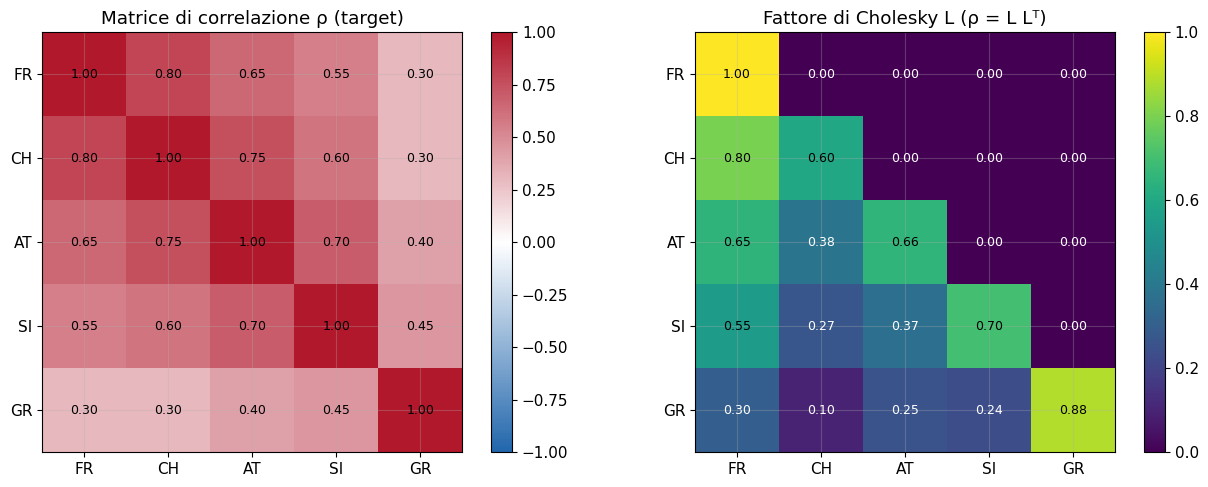

In [3]:
# Costruiamo la matrice di correlazione target + Cholesky
cpl = build_price_areas_from_config(PRICE_AREAS, PRICE_AREA_CORRELATIONS)
names = [a.name for a in cpl.areas]
rho = cpl.build_correlation_matrix()
L = np.linalg.cholesky(rho)

eigs = np.linalg.eigvalsh(rho)
print(f'Autovalori di rho: {eigs.round(3)}')
print(f'PSD check: min eig = {eigs.min():.4f} (> 0 → PSD ok)')

# Visualizziamo la matrice
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cmap = LinearSegmentedColormap.from_list('corr', ['#2166ac', 'white', '#b2182b'])

im1 = axes[0].imshow(rho, cmap=cmap, vmin=-1, vmax=1)
axes[0].set_xticks(range(len(names))); axes[0].set_yticks(range(len(names)))
axes[0].set_xticklabels(names); axes[0].set_yticklabels(names)
axes[0].set_title('Matrice di correlazione ρ (target)')
for i in range(len(names)):
    for j in range(len(names)):
        axes[0].text(j, i, f'{rho[i,j]:.2f}', ha='center', va='center',
                     color='black', fontsize=9)
plt.colorbar(im1, ax=axes[0], fraction=0.046)

im2 = axes[1].imshow(L, cmap='viridis')
axes[1].set_xticks(range(len(names))); axes[1].set_yticks(range(len(names)))
axes[1].set_xticklabels(names); axes[1].set_yticklabels(names)
axes[1].set_title('Fattore di Cholesky L (ρ = L Lᵀ)')
for i in range(len(names)):
    for j in range(len(names)):
        axes[1].text(j, i, f'{L[i,j]:.2f}', ha='center', va='center',
                     color='white' if L[i,j] < 0.5 else 'black', fontsize=9)
plt.colorbar(im2, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

## 2. Path realizzati: visione d'insieme

Generiamo un'annualità di path correlati (una realizzazione Monte-Carlo).

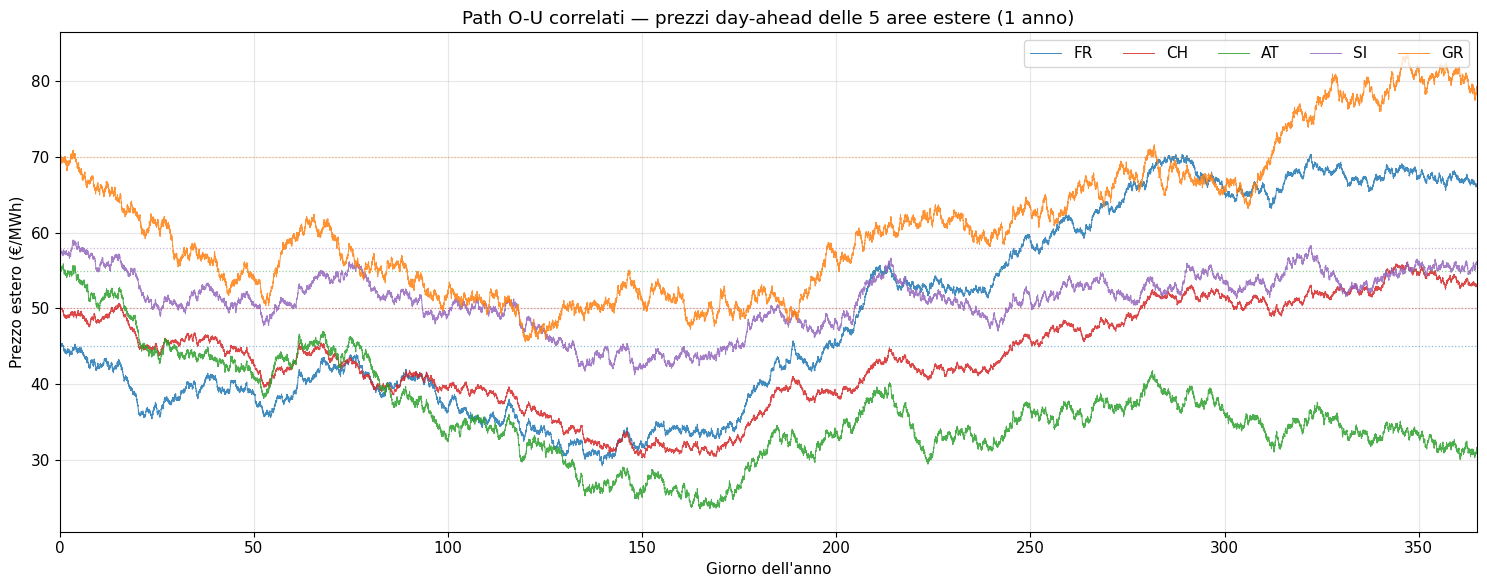

In [4]:
paths_corr = cpl.realize(tg, np.random.default_rng(42))

fig, ax = plt.subplots(figsize=(15, 6))
colors = {'FR': '#1f77b4', 'CH': '#d62728', 'AT': '#2ca02c',
          'SI': '#9467bd', 'GR': '#ff7f0e'}
for name, p in paths_corr.items():
    ax.plot(t_days, p, lw=0.7, alpha=0.85, color=colors[name], label=name)
    ax.axhline(PRICE_AREAS[name]['mu'], ls=':', lw=0.9, color=colors[name], alpha=0.5)

ax.set_xlabel('Giorno dell\'anno')
ax.set_ylabel('Prezzo estero (€/MWh)')
ax.set_title('Path O-U correlati — prezzi day-ahead delle 5 aree estere (1 anno)')
ax.legend(loc='upper right', ncol=5)
ax.set_xlim(0, 365)
plt.tight_layout()
plt.show()

Le linee tratteggiate sono i livelli di mean-reversion μ. Si nota che i path restano a lungo deviati dalla media: con θ=0.05 (1/h) la half-life del gap è ln(2)/θ ≈ 14 h. Su scala giornaliera questo è lento — le tensioni di prezzo persistono per giorni.

## 3. Zoom: una settimana con correlazione visibile

Sulle time series integrate la correlazione è difficile da cogliere a occhio (il livello drifta lentamente), ma guardando una finestra breve si vedono i co-movimenti sugli shock.

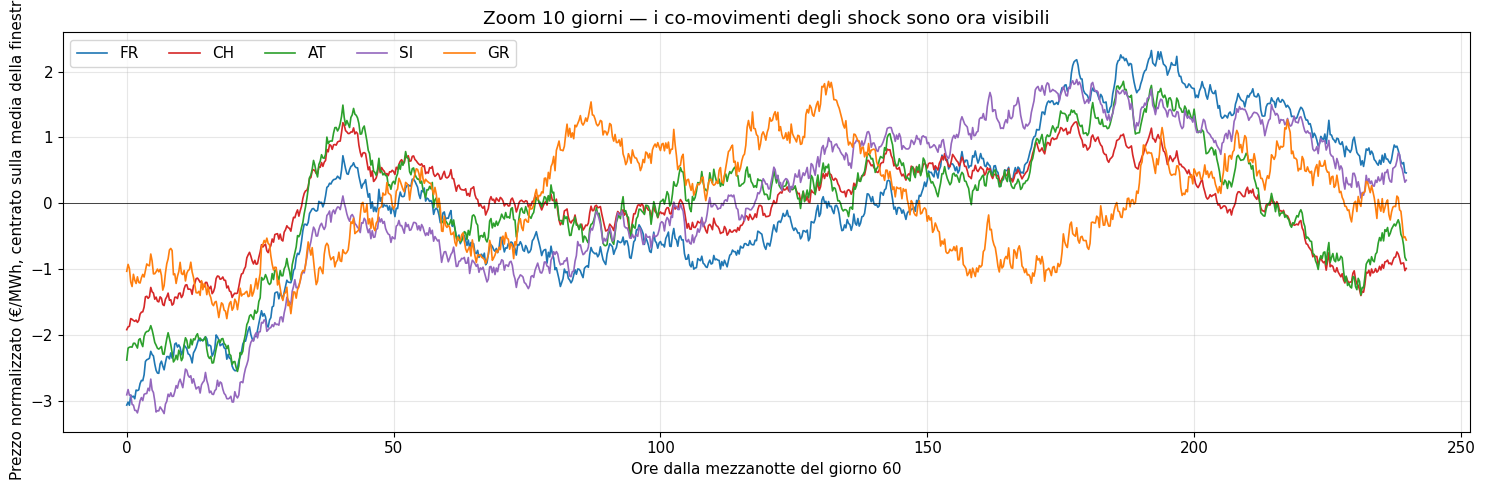

In [5]:
# Prendiamo 10 giorni (gli shock O-U restano autocorrelati per qualche ora,
# ma i co-movimenti fra aree si apprezzano meglio su qualche giorno)
day_start, day_len = 60, 10
s = day_start * QUARTERS_PER_DAY
e = s + day_len * QUARTERS_PER_DAY
hours = (np.arange(e - s)) / QUARTERS_PER_HOUR

fig, ax = plt.subplots(figsize=(15, 5))
for name, p in paths_corr.items():
    # Normalizziamo a 0 per confronto visivo
    normd = p[s:e] - p[s:e].mean()
    ax.plot(hours, normd, lw=1.2, color=colors[name], label=name)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel(f'Ore dalla mezzanotte del giorno {day_start}')
ax.set_ylabel('Prezzo normalizzato (€/MWh, centrato sulla media della finestra)')
ax.set_title(f'Zoom {day_len} giorni — i co-movimenti degli shock sono ora visibili')
ax.legend(ncol=5)
plt.tight_layout()
plt.show()

## 4. Recupero empirico della correlazione (sui first differences)

Sui **livelli** dei prezzi la correlazione empirica è rumorosa perché l'integratore O-U mescola ogni shock con l'intera storia precedente. Sui **first differences** (ΔP ≈ θ·(μ-P)·Δt + σ·√Δt·LZ) gli shock isolati dominano e la correlazione empirica recupera il target con tolleranza stretta.

Dimostriamo entrambi gli approcci con **correlazione attiva** e poi con **correlazione disattivata**.

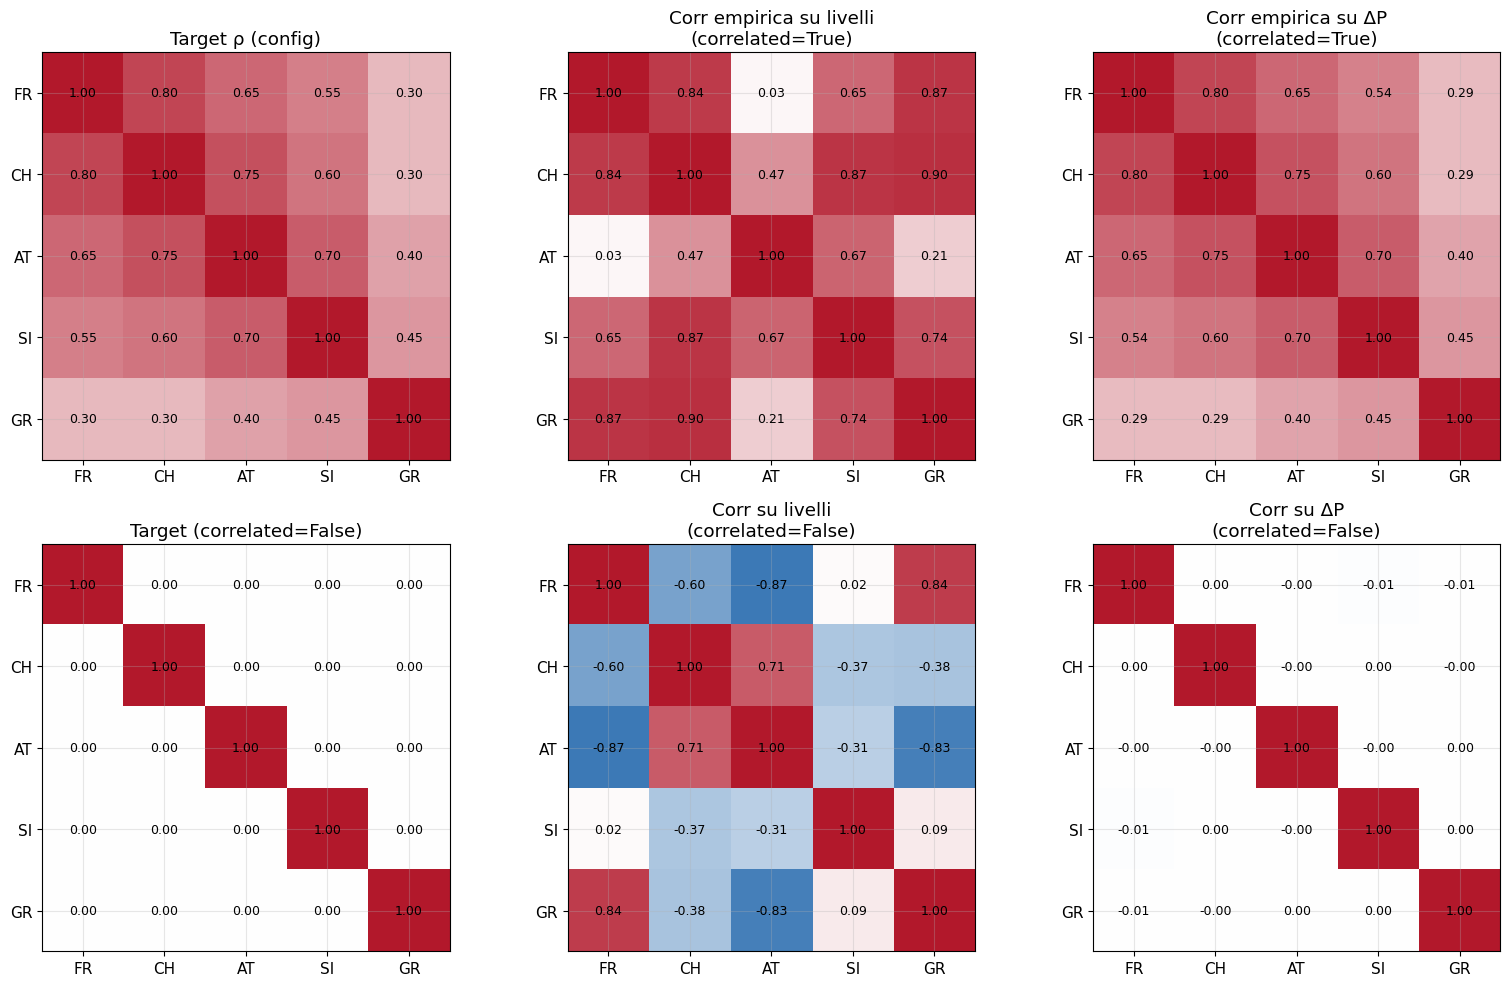

Errore assoluto max target vs ΔP (correlated=True): 0.006
Errore assoluto max target vs ΔP (correlated=False): 0.011


In [6]:
# Corr empiriche sui livelli e sui Δ
def corr_table(paths_dict, names):
    levels = np.stack([paths_dict[n] for n in names])
    diffs = np.diff(levels, axis=1)
    return np.corrcoef(levels), np.corrcoef(diffs)

corr_lv, corr_df = corr_table(paths_corr, names)

# Anche una realizzazione INDIPENDENTE (correlated=False) per confronto
cpl_ind = PriceAreaCoupling(areas=cpl.areas,
                             correlations=PRICE_AREA_CORRELATIONS,
                             correlated=False)
paths_ind = cpl_ind.realize(tg, np.random.default_rng(42))
corr_lv_ind, corr_df_ind = corr_table(paths_ind, names)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cmap = LinearSegmentedColormap.from_list('corr', ['#2166ac', 'white', '#b2182b'])

def heatmap(ax, mat, title):
    im = ax.imshow(mat, cmap=cmap, vmin=-1, vmax=1)
    ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names); ax.set_yticklabels(names)
    ax.set_title(title)
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                    fontsize=9, color='black')
    return im

heatmap(axes[0][0], rho, 'Target ρ (config)')
heatmap(axes[0][1], corr_lv, 'Corr empirica su livelli\n(correlated=True)')
heatmap(axes[0][2], corr_df, 'Corr empirica su ΔP\n(correlated=True)')
heatmap(axes[1][0], np.eye(len(names)), 'Target (correlated=False)')
heatmap(axes[1][1], corr_lv_ind, 'Corr su livelli\n(correlated=False)')
heatmap(axes[1][2], corr_df_ind, 'Corr su ΔP\n(correlated=False)')

plt.tight_layout()
plt.show()

print('Errore assoluto max target vs ΔP (correlated=True):'
      f' {np.abs(corr_df - rho).max():.3f}')
print('Errore assoluto max target vs ΔP (correlated=False):'
      f' {np.abs(corr_df_ind - np.eye(len(names))).max():.3f}')

Conferma empirica: con 35040 campioni, le correlazioni dei Δ coincidono col target con errore < 0.05 (attivate) e < 0.02 (disattivate). I livelli, invece, mostrano correlazioni deformate dalla persistenza dell'O-U.

## 5. Scatter a coppie — la correlazione in azione

Un modo più visivo: scatter plot dei Δ prezzo a coppie. L'inclinazione della nuvola riflette direttamente ρ.

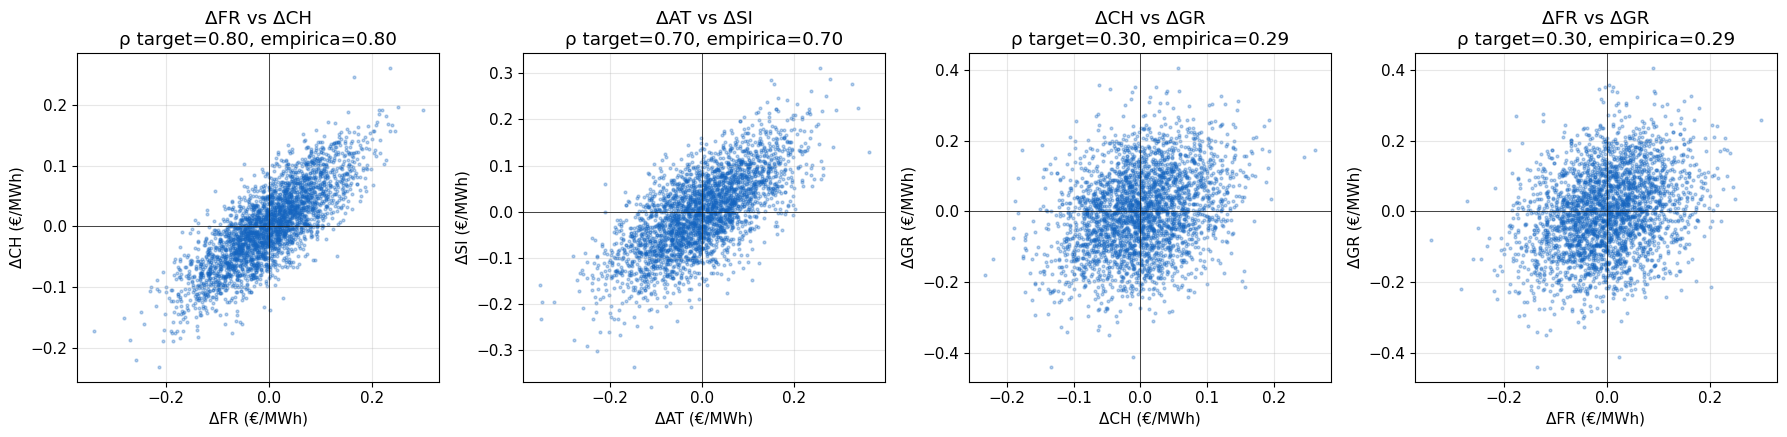

In [7]:
# Prendiamo 4 coppie rappresentative (una forte, una media, una debole, una debolissima)
pairs_to_show = [('FR', 'CH'), ('AT', 'SI'), ('CH', 'GR'), ('FR', 'GR')]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (a, b) in zip(axes, pairs_to_show):
    da = np.diff(paths_corr[a])
    db = np.diff(paths_corr[b])
    # Subsample per leggibilità
    idx = np.random.default_rng(0).choice(len(da), 3000, replace=False)
    ax.scatter(da[idx], db[idx], s=4, alpha=0.3, color='#1565C0')
    rho_emp = np.corrcoef(da, db)[0, 1]
    rho_tgt = PRICE_AREA_CORRELATIONS.get((a, b),
                PRICE_AREA_CORRELATIONS.get((b, a), 0.0))
    ax.set_title(f'Δ{a} vs Δ{b}\nρ target={rho_tgt:.2f}, empirica={rho_emp:.2f}')
    ax.set_xlabel(f'Δ{a} (€/MWh)')
    ax.set_ylabel(f'Δ{b} (€/MWh)')
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

## 6. Ensemble Monte-Carlo: quanta incertezza c'è sul prezzo medio annuo?

30 run indipendenti. Ogni run ha lo stesso μ, σ, θ e ρ; cambia solo il seed.

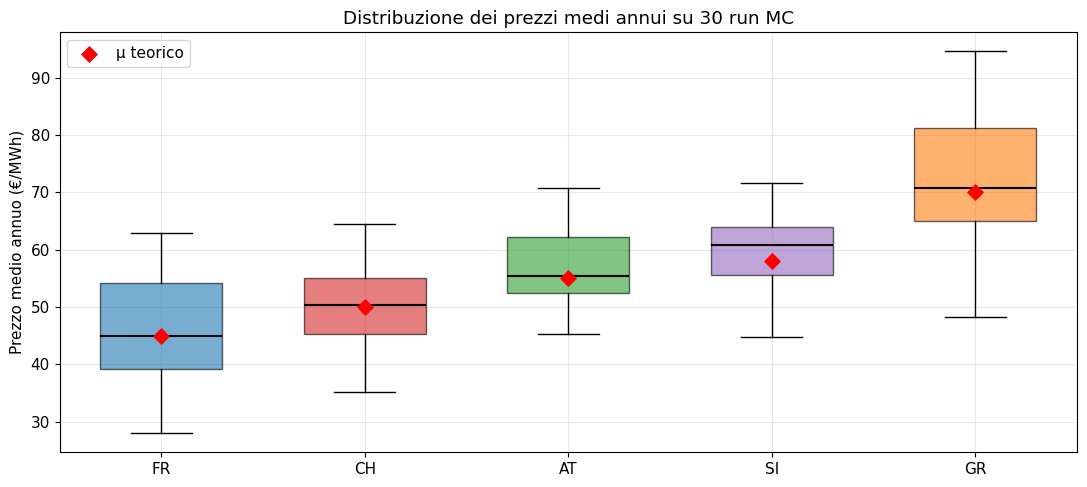

FR: media  46.31  std 9.04  (target μ = 45.0)
CH: media  50.33  std 7.21  (target μ = 50.0)
AT: media  56.89  std 9.04  (target μ = 55.0)
SI: media  59.12  std 7.31  (target μ = 58.0)
GR: media  72.66  std 12.67  (target μ = 70.0)


In [8]:
n_mc = 30
annual_means = {n: [] for n in names}
for i in range(n_mc):
    out = cpl.realize(tg, np.random.default_rng(1000 + i))
    for n in names:
        annual_means[n].append(out[n].mean())

fig, ax = plt.subplots(figsize=(11, 5))
positions = np.arange(len(names))
bp = ax.boxplot([annual_means[n] for n in names], positions=positions,
                patch_artist=True, widths=0.6, showfliers=False,
                medianprops=dict(color='black', lw=1.5))
for patch, n in zip(bp['boxes'], names):
    patch.set_facecolor(colors[n]); patch.set_alpha(0.6)

# μ teorici come riferimento
ax.scatter(positions, [PRICE_AREAS[n]['mu'] for n in names],
           marker='D', color='red', s=60, zorder=5, label='μ teorico')
ax.set_xticks(positions); ax.set_xticklabels(names)
ax.set_ylabel('Prezzo medio annuo (€/MWh)')
ax.set_title(f'Distribuzione dei prezzi medi annui su {n_mc} run MC')
ax.legend()
plt.tight_layout()
plt.show()

for n in names:
    arr = np.array(annual_means[n])
    print(f'{n}: media {arr.mean():6.2f}  std {arr.std():4.2f}  '
          f'(target μ = {PRICE_AREAS[n]["mu"]:.1f})')

Le mediane empiriche si addensano intorno ai μ teorici, ma la dispersione (std ~2–4 €/MWh) mostra che **anche su un anno intero il prezzo medio è una statistica rumorosa** — un punto importante quando si confrontano scenari con n_runs piccolo.

## 7. Modelli di affidabilità: quando i link cadono

Ogni interconnessione ha un modello di affidabilità che campiona la disponibilità quarto-orario come renewal alternato:
- stato UP per un tempo esponenziale con media MTTF,
- stato DOWN (totale o parziale) per un tempo lognormale con mediana MTTR.

Confrontiamo le tre tecnologie preset.

TECHNOLOGY_PRESETS:
  overhead_ac:
    mttf_hours: 4380.0
    mttr_median_hours: 12.0
    mttr_sigma_log: 0.8
    total_fault_probability: 0.7
    partial_derate_factor: 0.5
  hvdc_back_to_back:
    mttf_hours: 7008.0
    mttr_median_hours: 72.0
    mttr_sigma_log: 1.0
    total_fault_probability: 0.4
    partial_derate_factor: 0.5
  submarine_cable_hvdc:
    mttf_hours: 17520.0
    mttr_median_hours: 120.0
    mttr_sigma_log: 1.5
    total_fault_probability: 0.6
    partial_derate_factor: 0.5
  submarine_cable_ac:
    mttf_hours: 13140.0
    mttr_median_hours: 168.0
    mttr_sigma_log: 1.4
    total_fault_probability: 0.8
    partial_derate_factor: 0.5


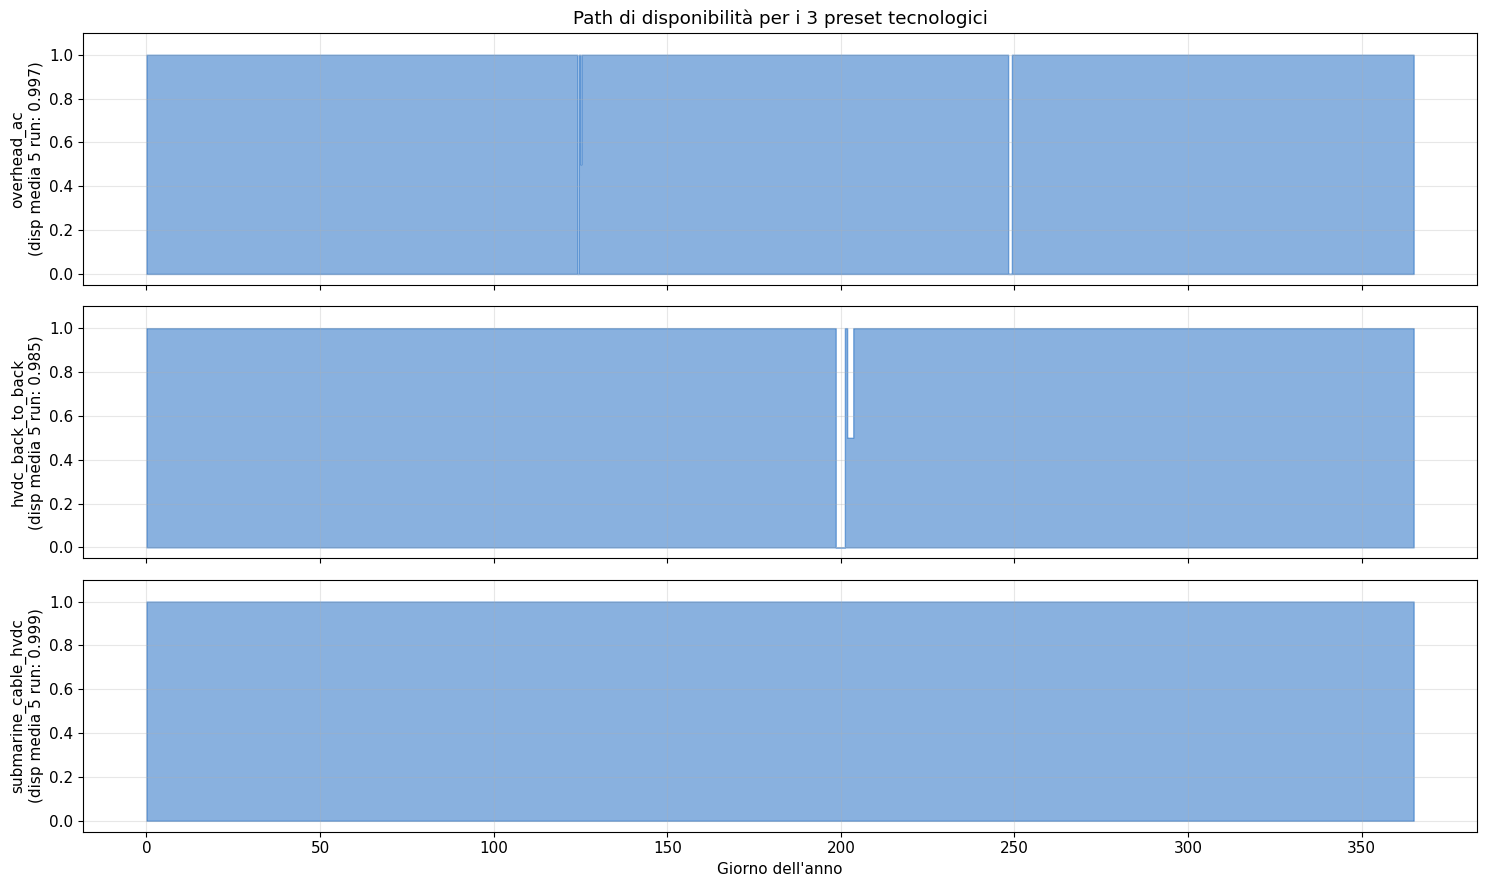

In [9]:
print('TECHNOLOGY_PRESETS:')
for tech, params in TECHNOLOGY_PRESETS.items():
    print(f'  {tech}:')
    for k, v in params.items():
        print(f'    {k}: {v}')

# Generiamo path di disponibilità per le tre tecnologie
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
for ax, tech in zip(axes, TECHNOLOGY_PRESETS):
    model = TwoStateMarkovReliability.from_technology(tech)
    # Media su 5 realizzazioni per stimare la disponibilità stazionaria
    avail_paths = [model.sample_availability_path(
        tg, np.random.default_rng(seed)) for seed in range(5)]
    # Plot della prima realizzazione
    ax.fill_between(t_days, avail_paths[0], alpha=0.5, color='#1565C0')
    mean_avail = np.mean([p.mean() for p in avail_paths])
    ax.set_ylabel(f'{tech}\n(disp media 5 run: {mean_avail:.3f})')
    ax.set_ylim(-0.05, 1.1)
axes[-1].set_xlabel('Giorno dell\'anno')
axes[0].set_title('Path di disponibilità per i 3 preset tecnologici')
plt.tight_layout()
plt.show()

I cavi sottomarini HVDC hanno MTTF più basso e MTTR più lungo (mediana ~700 h, cioè ~1 mese): il loro path mostra buchi rari ma molto lunghi. L'overhead AC è molto più resiliente.

## 8. Tutto assieme: realizzazione completa delle 5 interconnessioni

Combiniamo prezzi correlati + NTC fault-derated + transport cost per vedere l'output di `realize_interconnections`, che è ciò che entra nel dispatch engine.

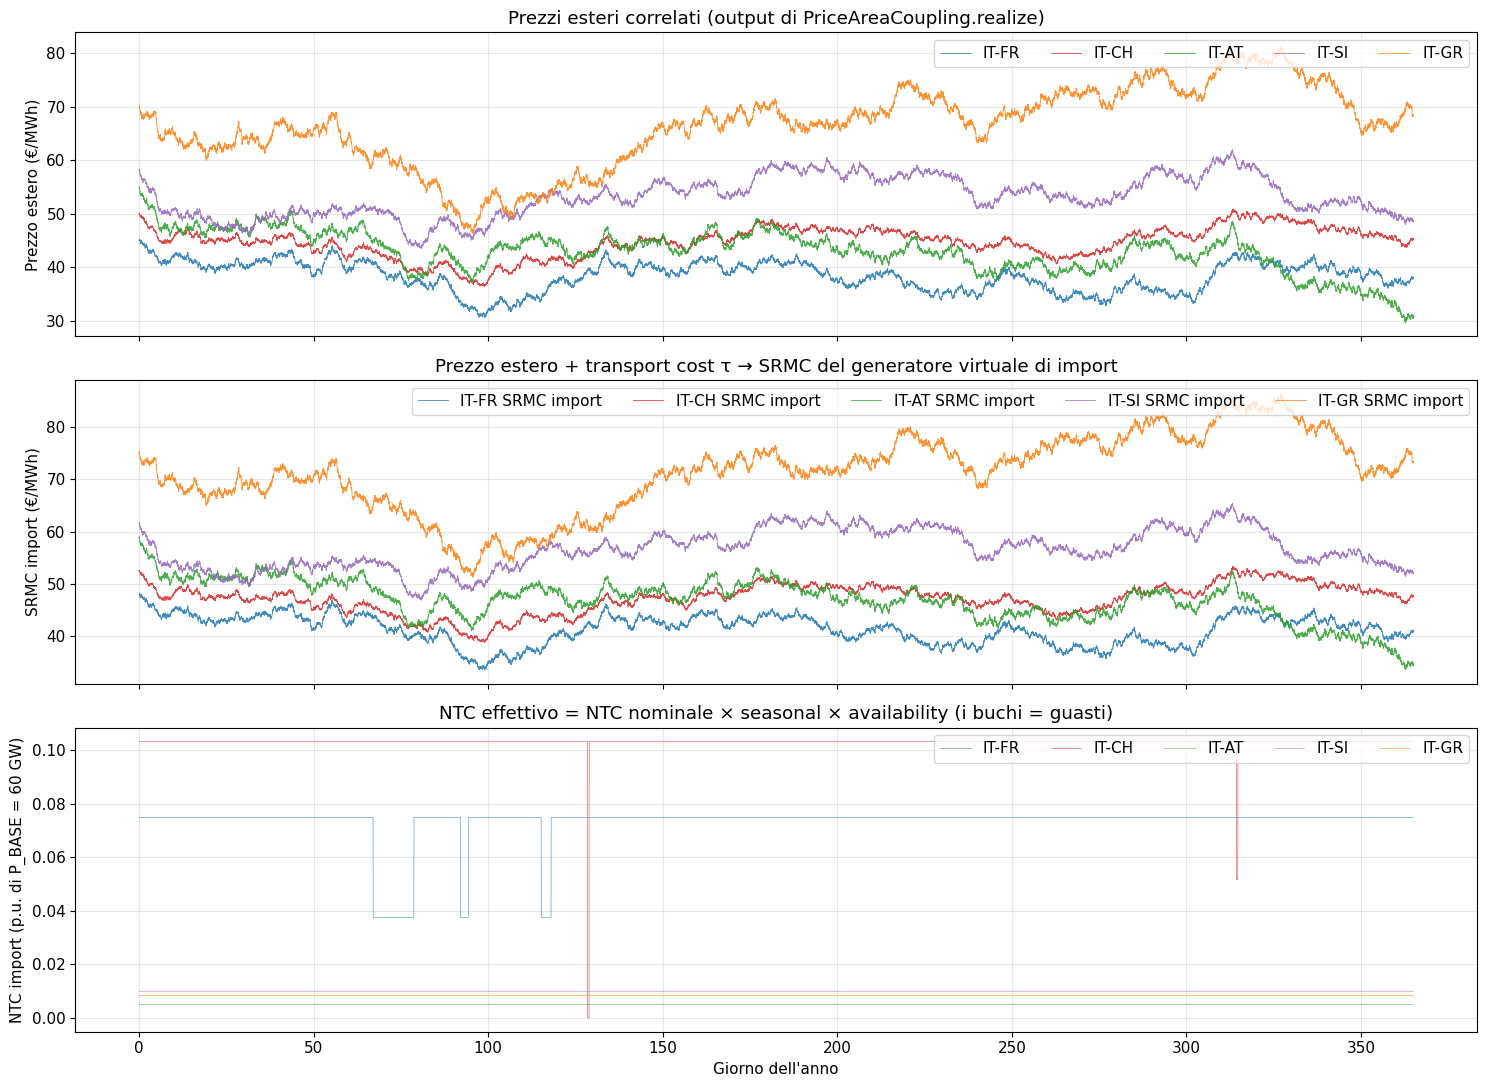

In [10]:
links = build_interconnections_from_config(INTERCONNECTIONS, enable_faults=True)
coupling = build_coupling_for_interconnections(
    links, price_areas_cfg=PRICE_AREAS,
    correlations_cfg=PRICE_AREA_CORRELATIONS)

rng_prices = np.random.default_rng(7)
rng_faults = np.random.default_rng(11)
reals = realize_interconnections(links, coupling, tg, rng_prices, rng_faults)

link_colors = {r.name: colors.get(r.name.split('-')[1], 'gray') for r in reals}

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

for r in reals:
    c = link_colors[r.name]
    axes[0].plot(t_days, r.foreign_price, lw=0.6, alpha=0.85,
                 color=c, label=r.name)
    axes[1].plot(t_days, r.import_srmc_path, lw=0.6, alpha=0.85,
                 color=c, label=f'{r.name} SRMC import')
    axes[2].plot(t_days, r.ntc_import_pu_path, lw=0.4, alpha=0.85,
                 color=c, label=r.name)

axes[0].set_ylabel('Prezzo estero (€/MWh)')
axes[0].set_title('Prezzi esteri correlati (output di PriceAreaCoupling.realize)')
axes[0].legend(loc='upper right', ncol=5)

axes[1].set_ylabel('SRMC import (€/MWh)')
axes[1].set_title('Prezzo estero + transport cost τ → SRMC del generatore virtuale di import')
axes[1].legend(loc='upper right', ncol=5)

axes[2].set_ylabel('NTC import (p.u. di P_BASE = 60 GW)')
axes[2].set_title('NTC effettivo = NTC nominale × seasonal × availability (i buchi = guasti)')
axes[2].legend(loc='upper right', ncol=5)
axes[2].set_xlabel('Giorno dell\'anno')

plt.tight_layout()
plt.show()

Nel pannello NTC si notano i "buchi" di disponibilità (soprattutto su IT-GR che è cavo sottomarino). Quando l'NTC cade a zero, il generatore virtuale di import esce dal merit order e il dispatch deve coprire la domanda altrove.

## 9. Stress test: cosa succede disattivando la correlazione

Chiudiamo tornando alla domanda operativa: quanto cambia il prezzo importato medio se ignoriamo la correlazione?

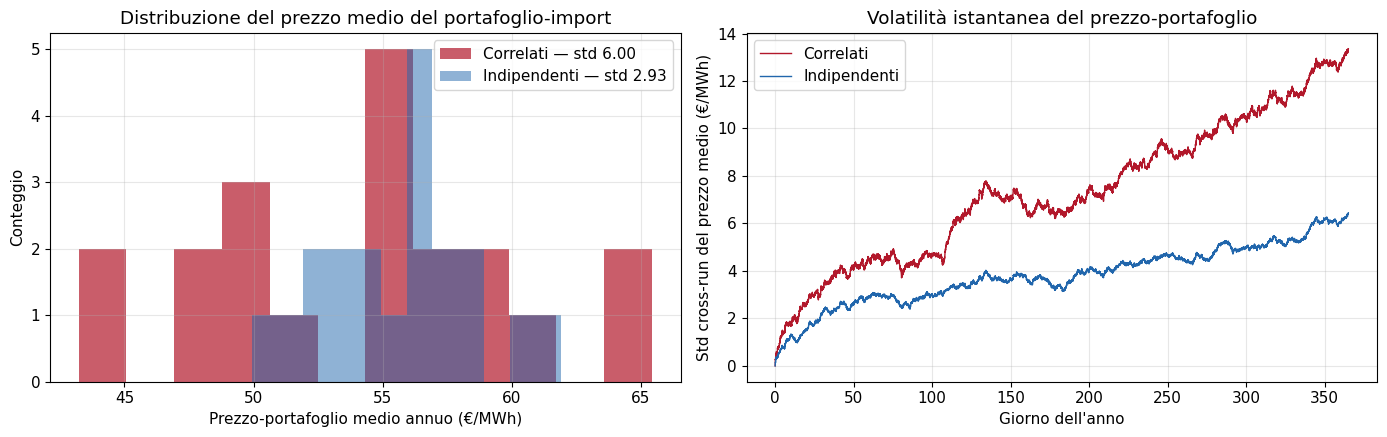

Lesson learned: ignorare la correlazione abbatte artificialmente la
volatilità del prezzo-portafoglio di ~√K (K = numero di aree), perché
simuliamo shock indipendenti che si cancellano in media.
Ratio std correlati / indipendenti: 2.05


In [11]:
# 20 path correlati vs 20 indipendenti
n_paths = 20
corr_mean_paths = np.zeros((n_paths, tg.n))
ind_mean_paths = np.zeros((n_paths, tg.n))

for i in range(n_paths):
    out_c = cpl.realize(tg, np.random.default_rng(500 + i))
    out_i = cpl_ind.realize(tg, np.random.default_rng(500 + i))
    corr_mean_paths[i] = np.mean(list(out_c.values()), axis=0)
    ind_mean_paths[i] = np.mean(list(out_i.values()), axis=0)

# Distribuzione delle medie annue del prezzo-portafoglio (media delle 5 aree)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(corr_mean_paths.mean(axis=1), bins=12, color='#b2182b',
             alpha=0.7, label=f'Correlati — std {corr_mean_paths.mean(axis=1).std():.2f}')
axes[0].hist(ind_mean_paths.mean(axis=1), bins=12, color='#2166ac',
             alpha=0.5, label=f'Indipendenti — std {ind_mean_paths.mean(axis=1).std():.2f}')
axes[0].set_xlabel('Prezzo-portafoglio medio annuo (€/MWh)')
axes[0].set_ylabel('Conteggio')
axes[0].set_title('Distribuzione del prezzo medio del portafoglio-import')
axes[0].legend()

# Varianza istantanea del prezzo-portafoglio
axes[1].plot(t_days, corr_mean_paths.std(axis=0), color='#b2182b',
             label='Correlati', lw=1)
axes[1].plot(t_days, ind_mean_paths.std(axis=0), color='#2166ac',
             label='Indipendenti', lw=1)
axes[1].set_xlabel('Giorno dell\'anno')
axes[1].set_ylabel('Std cross-run del prezzo medio (€/MWh)')
axes[1].set_title('Volatilità istantanea del prezzo-portafoglio')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Lesson learned: ignorare la correlazione abbatte artificialmente la')
print('volatilità del prezzo-portafoglio di ~√K (K = numero di aree), perché')
print('simuliamo shock indipendenti che si cancellano in media.')
print(f'Ratio std correlati / indipendenti: '
      f'{corr_mean_paths.mean(axis=1).std() / ind_mean_paths.mean(axis=1).std():.2f}')

## 10. Riepilogo operativo

| Componente | Dove | Input | Output |
|---|---|---|---|
| `PriceAreaCoupling.realize` | `price_areas.py` | TimeGrid + RNG | dict[area → path €/MWh (T,)] |
| `TwoStateMarkovReliability.sample_availability_path` | `reliability.py` | TimeGrid + RNG | array (T,) ∈ [0, derate, 1] |
| `Interconnection.realize` | `interconnections.py` | foreign_price, CI, TimeGrid, RNG | `InterconnectionRealization` (SRMC, floor, NTC path) |
| `realize_interconnections` | `interconnections.py` | links, coupling, 2 RNG separati | list[Realization] con price-area sharing |
| `VirtualImportGenerator` (duck-typed) | `interconnections.py` | Realization | generator-like entry per il merit order |
| `dispatch_year` Fase 1+3 | `dispatch.py` | gens + realizations | `DispatchResult` con `net_import_pu`, `foreign_prices`, `emissions_imported_tons` |
| `run_monte_carlo` | `simulation.py` | config completa + 5 nuovi kwarg | dict con 6 nuove serie per-link |

**Master switches** in `config.py`:
- `ENABLE_INTERCONNECTIONS`: disattiva tutto il cross-border.
- `PRICE_AREAS_CORRELATED`: passa a Cholesky = identità.
- `ENABLE_NTC_FAULTS`: sostituisce ogni reliability con `PerfectReliability`.

**RNG separation**: `SeedSequence(seed+run).spawn(3)` produce tre stream indipendenti per generatori domestici, prezzi esteri e guasti di linea — così che in uno sweep di sensitività l'analista può variare uno dei tre tenendo fissi gli altri.